In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GroupedRFResidualNet(nn.Module):
    """
    Structured residual model for delay-aligned RF tensor.

    Input from Dataset:
        x:        [B, 1536, Z, X, Y]
        baseline: [B, 2,    Z, X, Y]

    Channel order in x:
        1536 = 128 receive channels × 3 angles × 4 components

    Components:
        RC_real, RC_imag, CR_real, CR_imag

    Structure:
        1) grouped 1x1x1 conv:
           each receive channel independently fuses 3 angles × 4 components

        2) 1x1x1 channel fusion:
           fuse all receive channels into low-dimensional features

        3) small 3D spatial residual block

        4) output residual real/imag:
           pred = baseline + residual
    """

    def __init__(
        self,
        n_rx=128,
        n_angle=3,
        n_comp=4,
        per_rx_features=2,
        hidden=64,
        out_channels=2,
    ):
        super().__init__()

        self.n_rx = n_rx
        self.n_angle = n_angle
        self.n_comp = n_comp

        in_channels = n_rx * n_angle * n_comp
        grouped_out = n_rx * per_rx_features

        # Each RX group sees: 3 angles × 4 components = 12 channels.
        # It outputs per_rx_features channels.
        self.rx_group_fusion = nn.Sequential(
            nn.Conv3d(
                in_channels=in_channels,
                out_channels=grouped_out,
                kernel_size=1,
                groups=n_rx,
                bias=True,
            ),
            nn.InstanceNorm3d(grouped_out, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

        # Fuse receive-channel features.
        self.channel_fusion = nn.Sequential(
            nn.Conv3d(grouped_out, hidden, kernel_size=1, padding=0),
            nn.InstanceNorm3d(hidden, affine=True),
            nn.LeakyReLU(0.1, inplace=True),
        )

        # Small spatial residual correction block.
        self.spatial = nn.Sequential(
            nn.Conv3d(hidden, hidden, kernel_size=3, padding=1),
            nn.InstanceNorm3d(hidden, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv3d(hidden, hidden, kernel_size=3, padding=1),
            nn.InstanceNorm3d(hidden, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv3d(hidden, 32, kernel_size=3, padding=1),
            nn.InstanceNorm3d(32, affine=True),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv3d(32, out_channels, kernel_size=1, padding=0),
        )

        # Start close to baseline.
        last = self.spatial[-1]
        nn.init.zeros_(last.weight)
        nn.init.zeros_(last.bias)

    def forward(self, x, baseline):
        feat = self.rx_group_fusion(x)
        feat = self.channel_fusion(feat)
        residual = self.spatial(feat)
        pred = baseline + residual
        return pred

In [2]:
from pathlib import Path
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np


def complex_abs_2ch(x):
    """
    x: [B, 2, Z, X, Y]
    """
    return torch.sqrt(x[:, 0:1] ** 2 + x[:, 1:2] ** 2 + 1e-8)


def infer_category_from_path(path):
    p = str(path).lower()
    for cat in ["carotid", "muscle", "phantom", "simu_point"]:
        if cat in p:
            return cat
    return "unknown"


@torch.no_grad()
def evaluate_full_test_set(
    model,
    dataset,
    device,
    batch_size=4,
    save_csv_path=None,
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    model.eval()

    rows = []

    for batch in loader:
        x = batch["input"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        b = batch["baseline"].to(device, non_blocking=True)

        scale = batch["scale"].to(device)
        if scale.ndim == 1:
            scale = scale.view(-1, 1, 1, 1, 1)

        pred = model(x, b)

        # Denormalize if dataset used normalize=True.
        pred_raw = pred * scale
        y_raw = y * scale
        b_raw = b * scale

        # Per-sample complex L1.
        pred_l1 = torch.mean(torch.abs(pred_raw - y_raw), dim=(1, 2, 3, 4))
        base_l1 = torch.mean(torch.abs(b_raw - y_raw), dim=(1, 2, 3, 4))

        # Per-sample envelope L1.
        pred_abs = complex_abs_2ch(pred_raw)
        y_abs = complex_abs_2ch(y_raw)
        b_abs = complex_abs_2ch(b_raw)

        pred_abs_l1 = torch.mean(torch.abs(pred_abs - y_abs), dim=(1, 2, 3, 4))
        base_abs_l1 = torch.mean(torch.abs(b_abs - y_abs), dim=(1, 2, 3, 4))

        paths = batch["path"]

        for i, path in enumerate(paths):
            pl1 = float(pred_l1[i].cpu())
            bl1 = float(base_l1[i].cpu())
            pa1 = float(pred_abs_l1[i].cpu())
            ba1 = float(base_abs_l1[i].cpu())

            rows.append({
                "path": path,
                "category": infer_category_from_path(path),

                "pred_complex_l1": pl1,
                "base_complex_l1": bl1,
                "complex_improvement": 1.0 - pl1 / (bl1 + 1e-12),
                "complex_better": pl1 < bl1,

                "pred_abs_l1": pa1,
                "base_abs_l1": ba1,
                "abs_improvement": 1.0 - pa1 / (ba1 + 1e-12),
                "abs_better": pa1 < ba1,
            })

    df = pd.DataFrame(rows)

    if save_csv_path is not None:
        save_csv_path = Path(save_csv_path)
        save_csv_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_csv_path, index=False)
        print(f"Saved per-sample metrics to: {save_csv_path}")

    return df


def summarize_test_metrics(df):
    overall = {
        "n": len(df),

        "complex_pred_mean": df["pred_complex_l1"].mean(),
        "complex_base_mean": df["base_complex_l1"].mean(),
        "complex_improvement_mean": df["complex_improvement"].mean(),
        "complex_better_rate": df["complex_better"].mean(),

        "abs_pred_mean": df["pred_abs_l1"].mean(),
        "abs_base_mean": df["base_abs_l1"].mean(),
        "abs_improvement_mean": df["abs_improvement"].mean(),
        "abs_better_rate": df["abs_better"].mean(),
    }

    print("\n================ Overall test summary ================")
    print(f"Samples: {overall['n']}")

    print("\n[Complex L1]")
    print(f"pred mean       : {overall['complex_pred_mean']:.4e}")
    print(f"baseline mean   : {overall['complex_base_mean']:.4e}")
    print(f"mean improvement: {overall['complex_improvement_mean']*100:.2f}%")
    print(f"better rate     : {overall['complex_better_rate']*100:.2f}%")

    print("\n[Envelope abs L1]")
    print(f"pred mean       : {overall['abs_pred_mean']:.4e}")
    print(f"baseline mean   : {overall['abs_base_mean']:.4e}")
    print(f"mean improvement: {overall['abs_improvement_mean']*100:.2f}%")
    print(f"better rate     : {overall['abs_better_rate']*100:.2f}%")

    print("\n================ Per-category summary ================")
    cat_summary = df.groupby("category").agg(
        n=("path", "count"),

        complex_pred_mean=("pred_complex_l1", "mean"),
        complex_base_mean=("base_complex_l1", "mean"),
        complex_improvement_mean=("complex_improvement", "mean"),
        complex_better_rate=("complex_better", "mean"),

        abs_pred_mean=("pred_abs_l1", "mean"),
        abs_base_mean=("base_abs_l1", "mean"),
        abs_improvement_mean=("abs_improvement", "mean"),
        abs_better_rate=("abs_better", "mean"),
    )

    display(cat_summary)

    return overall, cat_summary

In [3]:
from pathlib import Path
from torch.utils.data import DataLoader

from rf_learning_dataset import RFLearningDataset


root_dir = Path("/home/liujia/3DSSIM_1/RF_Image/Data")

train_root = root_dir / "train"
val_root   = root_dir / "val"
test_root  = root_dir / "test"

train_set = RFLearningDataset(
    root_dir=train_root,
    sample_group="/sample_000001",
    normalize=True,
)

val_set = RFLearningDataset(
    root_dir=val_root,
    sample_group="/sample_000001",
    normalize=True,
)

test_set = RFLearningDataset(
    root_dir=test_root,
    sample_group="/sample_000001",
    normalize=True,
)

train_loader = DataLoader(
    train_set,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_set,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_set,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Train samples:", len(train_set))
print("Val samples  :", len(val_set))
print("Test samples :", len(test_set))

batch = next(iter(train_loader))
print("input   :", batch["input"].shape)
print("label   :", batch["label"].shape)
print("baseline:", batch["baseline"].shape)

Train samples: 200
Val samples  : 40
Test samples : 40
input   : torch.Size([4, 1536, 16, 8, 8])
label   : torch.Size([4, 2, 16, 8, 8])
baseline: torch.Size([4, 2, 16, 8, 8])


In [4]:
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn.functional as F


def seed_everything(seed=20260522):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def complex_abs_2ch(x):
    return torch.sqrt(x[:, 0:1] ** 2 + x[:, 1:2] ** 2 + 1e-8)


def compute_loss(pred, label):
    loss_l1 = F.l1_loss(pred, label)

    pred_abs = complex_abs_2ch(pred)
    label_abs = complex_abs_2ch(label)
    loss_abs = F.l1_loss(pred_abs, label_abs)

    loss = loss_l1 + 0.1 * loss_abs
    return loss, loss_l1, loss_abs


@torch.no_grad()
def evaluate_normalized(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_l1 = 0.0
    total_abs = 0.0
    total_base_l1 = 0.0
    total_base_abs = 0.0
    n_batches = 0

    for batch in loader:
        x = batch["input"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        b = batch["baseline"].to(device, non_blocking=True)

        pred = model(x, b)

        loss, loss_l1, loss_abs = compute_loss(pred, y)

        base_l1 = F.l1_loss(b, y)
        base_abs = F.l1_loss(complex_abs_2ch(b), complex_abs_2ch(y))

        total_loss += loss.item()
        total_l1 += loss_l1.item()
        total_abs += loss_abs.item()
        total_base_l1 += base_l1.item()
        total_base_abs += base_abs.item()
        n_batches += 1

    total_loss /= max(n_batches, 1)
    total_l1 /= max(n_batches, 1)
    total_abs /= max(n_batches, 1)
    total_base_l1 /= max(n_batches, 1)
    total_base_abs /= max(n_batches, 1)

    improvement = 1.0 - total_l1 / (total_base_l1 + 1e-12)

    return {
        "loss": total_loss,
        "l1": total_l1,
        "abs": total_abs,
        "baseline_l1": total_base_l1,
        "baseline_abs": total_base_abs,
        "improvement": improvement,
    }


def train_model_jupyter(
    model,
    train_loader,
    val_loader,
    device,
    save_dir="checkpoints_grouped_rfnet",
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    print_every=5,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=1e-5,
    )

    best_val_l1 = float("inf")
    best_epoch = -1
    history = []

    init_val = evaluate_normalized(model, val_loader, device)
    print("\nInitial validation:")
    print(
        f"val_L1={init_val['l1']:.6e} | "
        f"baseline_L1={init_val['baseline_l1']:.6e} | "
        f"improvement={init_val['improvement']*100:.2f}%"
    )

    for epoch in range(1, num_epochs + 1):
        model.train()

        train_l1 = 0.0
        train_abs = 0.0
        train_loss = 0.0
        train_base = 0.0
        n_batches = 0

        for batch in train_loader:
            x = batch["input"].to(device, non_blocking=True)
            y = batch["label"].to(device, non_blocking=True)
            b = batch["baseline"].to(device, non_blocking=True)

            pred = model(x, b)
            loss, loss_l1, loss_abs = compute_loss(pred, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            with torch.no_grad():
                base_l1 = F.l1_loss(b, y)

            train_loss += loss.item()
            train_l1 += loss_l1.item()
            train_abs += loss_abs.item()
            train_base += base_l1.item()
            n_batches += 1

        scheduler.step()

        train_loss /= max(n_batches, 1)
        train_l1 /= max(n_batches, 1)
        train_abs /= max(n_batches, 1)
        train_base /= max(n_batches, 1)

        train_impr = 1.0 - train_l1 / (train_base + 1e-12)

        val_metrics = evaluate_normalized(model, val_loader, device)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_l1": train_l1,
            "train_abs": train_abs,
            "train_base": train_base,
            "train_impr": train_impr,
            "val_l1": val_metrics["l1"],
            "val_abs": val_metrics["abs"],
            "val_base": val_metrics["baseline_l1"],
            "val_impr": val_metrics["improvement"],
            "lr": scheduler.get_last_lr()[0],
        }
        history.append(row)

        if val_metrics["l1"] < best_val_l1:
            best_val_l1 = val_metrics["l1"]
            best_epoch = epoch

            torch.save(
                {
                    "epoch": epoch,
                    "model": model.state_dict(),
                    "best_val_l1": best_val_l1,
                    "history": history,
                },
                save_dir / "best_grouped_rf_residual_net.pth",
            )

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:04d} | "
                f"train_L1={train_l1:.6e} | "
                f"train_base={train_base:.6e} | "
                f"train_impr={train_impr*100:6.2f}% | "
                f"val_L1={val_metrics['l1']:.6e} | "
                f"val_base={val_metrics['baseline_l1']:.6e} | "
                f"val_impr={val_metrics['improvement']*100:6.2f}% | "
                f"lr={scheduler.get_last_lr()[0]:.2e}"
            )

    torch.save(
        model.state_dict(),
        save_dir / "final_grouped_rf_residual_net.pth",
    )

    print("\nTraining finished.")
    print(f"Best val L1 = {best_val_l1:.6e} at epoch {best_epoch}")
    print(f"Best checkpoint: {save_dir / 'best_grouped_rf_residual_net.pth'}")

    history_df = pd.DataFrame(history)
    return history_df

In [5]:
seed_everything(20260522)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

grouped_model_p4 = GroupedRFResidualNet(
    n_rx=128,
    n_angle=3,
    n_comp=4,
    per_rx_features=4,   # 这里从 2 改成 4
    hidden=64,
    out_channels=2,
).to(device)

n_params = sum(p.numel() for p in grouped_model_p4.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params/1e6:.3f} M")

history_grouped_p4 = train_model_jupyter(
    model=grouped_model_p4,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    save_dir="checkpoints_grouped_rfnet_p4",
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    print_every=5,
)

Device: cuda
Trainable parameters: 0.318 M

Initial validation:
val_L1=6.175455e-01 | baseline_L1=6.175455e-01 | improvement=0.00%
Epoch 0001 | train_L1=5.658994e-01 | train_base=6.481951e-01 | train_impr= 12.70% | val_L1=4.799496e-01 | val_base=6.175455e-01 | val_impr= 22.28% | lr=1.00e-03
Epoch 0005 | train_L1=3.890571e-01 | train_base=6.481951e-01 | train_impr= 39.98% | val_L1=4.318149e-01 | val_base=6.175455e-01 | val_impr= 30.08% | lr=9.94e-04
Epoch 0010 | train_L1=3.364207e-01 | train_base=6.481951e-01 | train_impr= 48.10% | val_L1=4.420361e-01 | val_base=6.175455e-01 | val_impr= 28.42% | lr=9.76e-04
Epoch 0015 | train_L1=2.667980e-01 | train_base=6.481951e-01 | train_impr= 58.84% | val_L1=4.369083e-01 | val_base=6.175455e-01 | val_impr= 29.25% | lr=9.46e-04
Epoch 0020 | train_L1=2.246116e-01 | train_base=6.481951e-01 | train_impr= 65.35% | val_L1=4.269342e-01 | val_base=6.175455e-01 | val_impr= 30.87% | lr=9.05e-04
Epoch 0025 | train_L1=2.118105e-01 | train_base=6.481951e-01 | t

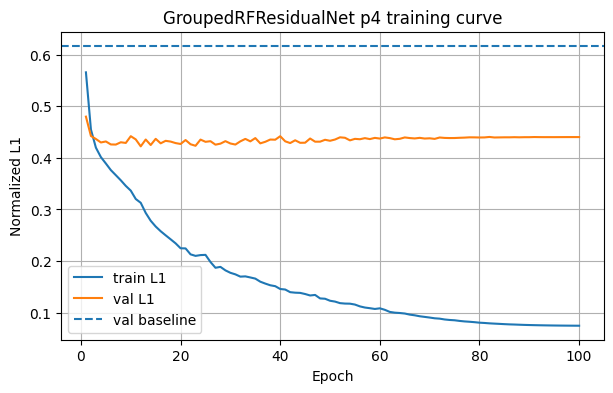

epoch         12.000000
train_loss     0.344585
train_l1       0.312798
train_abs      0.317872
train_base     0.648195
train_impr     0.517433
val_l1         0.422334
val_abs        0.397245
val_base       0.617546
val_impr       0.316108
lr             0.000965
Name: 11, dtype: float64


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history_grouped_p4["epoch"], history_grouped_p4["train_l1"], label="train L1")
plt.plot(history_grouped_p4["epoch"], history_grouped_p4["val_l1"], label="val L1")
plt.axhline(history_grouped_p4["val_base"].iloc[0], linestyle="--", label="val baseline")
plt.xlabel("Epoch")
plt.ylabel("Normalized L1")
plt.title("GroupedRFResidualNet p4 training curve")
plt.legend()
plt.grid(True)
plt.show()

best_row_p4 = history_grouped_p4.loc[history_grouped_p4["val_l1"].idxmin()]
print(best_row_p4)

In [7]:
ckpt_path = Path("checkpoints_grouped_rfnet_p4/best_grouped_rf_residual_net.pth")

best_grouped_model_p4 = GroupedRFResidualNet(
    n_rx=128,
    n_angle=3,
    n_comp=4,
    per_rx_features=4,
    hidden=64,
    out_channels=2,
).to(device)

ckpt = torch.load(ckpt_path, map_location=device)
best_grouped_model_p4.load_state_dict(ckpt["model"])

print(f"Loaded best grouped p4 model, epoch = {ckpt['epoch']}")
print(f"Best val L1 = {ckpt['best_val_l1']}")

df_test_grouped_p4 = evaluate_full_test_set(
    model=best_grouped_model_p4,
    dataset=test_set,
    device=device,
    batch_size=4,
    save_csv_path="test_metrics_grouped_rfnet_p4/test_per_sample_metrics.csv",
)

overall_grouped_p4, cat_summary_grouped_p4 = summarize_test_metrics(df_test_grouped_p4)

/tmp/ipykernel_303311/1620306735.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


Loaded best grouped p4 model, epoch = 12
Best val L1 = 0.4223341256380081
Saved per-sample metrics to: test_metrics_grouped_rfnet_p4/test_per_sample_metrics.csv

================ Overall test summary ================
Samples: 40

[Complex L1]
pred mean       : 6.9356e+03
baseline mean   : 9.2466e+03
mean improvement: 26.06%
better rate     : 87.50%

[Envelope abs L1]
pred mean       : 5.9911e+03
baseline mean   : 1.0161e+04
mean improvement: 42.39%
better rate     : 92.50%

================ Per-category summary ================


,n,complex_pred_mean,complex_base_mean,complex_improvement_mean,complex_better_rate,abs_pred_mean,abs_base_mean,abs_improvement_mean,abs_better_rate
category,,,,,,,,,
carotid,10,10439.290027,12587.376050,0.150547,0.8,6889.277637,12617.784839,0.413302,0.9
muscle,10,6021.511804,9612.763892,0.365475,1.0,4677.030847,9822.055981,0.553522,1.0
phantom,10,1618.379504,2632.813013,0.378010,1.0,1165.686786,2610.481665,0.549251,1.0
simu_point,10,9663.225671,12153.316504,0.148431,0.7,11232.604492,15591.750745,0.179722,0.8


In [ ]:
ckpt_path = Path("checkpoints_grouped_rfnet/best_grouped_rf_residual_net.pth")

best_grouped_model = GroupedRFResidualNet(
    n_rx=128,
    n_angle=3,
    n_comp=4,
    per_rx_features=2,
    hidden=64,
    out_channels=2,
).to(device)

ckpt = torch.load(ckpt_path, map_location=device)
best_grouped_model.load_state_dict(ckpt["model"])

print(f"Loaded best grouped model, epoch = {ckpt['epoch']}")
print(f"Best val L1 = {ckpt['best_val_l1']}")

df_test_grouped = evaluate_full_test_set(
    model=best_grouped_model,
    dataset=test_set,
    device=device,
    batch_size=4,
    save_csv_path="test_metrics_grouped_rfnet/test_per_sample_metrics.csv",
)

overall_grouped, cat_summary_grouped = summarize_test_metrics(df_test_grouped)